In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

#install.packages("tibble")
#install.packages("dplyr")
#install.packages(ggplot2)
#install.packages("caret")
#install.packages("glmnet")

library(tibble)
library(dplyr)
library(ggplot2)
library(caret)
library(pROC)
library(ROSE)
library(glmnet)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Want to understand how all the pieces fit together? Read R for Data
Science: https://r4ds.hadley.nz/
Loading required package: lattice
Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var

Loaded ROSE 0.0-4

Loading required package: Matrix
Loaded glmnet 4.1-8
In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages


In [3]:
%%R
# Defining GMIDs for Red Routes
# Am creating a list of GMIDs for processing
red_route_gmIDs  <- c(
     "2f95c748-f009-11ee-b966-fb353e7798cd",
  "65cfbfd6-f396-11ee-bb4e-fb353e7798cd",
  "f711e68e-f0e1-11ee-ba1f-fb353e7798cd",
  "171c50bc-f106-11ee-ba42-fb353e7798cd",
  "6d2ea45a-c839-11ee-a7fc-dd032dba19e8",
  "05c7c824-cab8-11ee-aa4d-1d66adf2f0c7",
  "96f7a614-f549-11ee-8afa-cb629b0d53e6",
  "cf831f42-f353-11ee-bb4e-fb353e7798cd",
  "f0eebb6a-f0dc-11ee-ba1e-fb353e7798cd",
  "9798fe24-f143-11ee-ba78-fb353e7798cd",
  "ce6465b6-f51b-11ee-8afa-cb629b0d53e6",
  "3d2d29ec-ef95-11ee-b966-fb353e7798cd",
  "d3698592-ef9d-11ee-b966-fb353e7798cd",
  "853ef120-cad3-11ee-909c-e1dc60cf66f9",
  "be857244-efc0-11ee-b966-fb353e7798cd",
  "f43b6a70-f01e-11ee-b966-fb353e7798cd",
  "fcc6fcd2-f013-11ee-b966-fb353e7798cd",
  "e7b934a8-ef1a-11ee-9385-ef789ffde1d3",
  "61b12e7a-f234-11ee-bb33-fb353e7798cd",
  "de933de8-f112-11ee-ba4d-fb353e7798cd",
  "8dbbbf1c-f0ef-11ee-ba29-fb353e7798cd",
  "fe973c9c-f53c-11ee-8afa-cb629b0d53e6",
  "ecebb942-f162-11ee-ba97-fb353e7798cd",
  "f755cf60-f132-11ee-ba6d-fb353e7798cd",
  "d24820c8-f197-11ee-babe-fb353e7798cd",
  "dd72fdec-f0cf-11ee-ba0d-fb353e7798cd",
  "286e019a-f204-11ee-bb07-fb353e7798cd",
  "41b67a28-f52f-11ee-8afa-cb629b0d53e6",
  "c0555ef0-f50f-11ee-8afa-cb629b0d53e6",
  "72a03d4a-efe9-11ee-b966-fb353e7798cd",
  "457dc5ee-f02a-11ee-b966-fb353e7798cd",
  "3151e9e2-eff3-11ee-b966-fb353e7798cd",
  "c25271be-f3a4-11ee-bb4e-fb353e7798cd",
  "2a61b8a8-f528-11ee-8afa-cb629b0d53e6",
  "01e65360-efd4-11ee-b966-fb353e7798cd",
  "1bbbfbae-c839-11ee-a7fc-dd032dba19e8",
  "f41cbd44-eff8-11ee-b966-fb353e7798cd",
  "aa5dbcd2-ef10-11ee-9385-ef789ffde1d3",
  "84d96f18-f214-11ee-bb13-fb353e7798cd",
  "94c53148-eeed-11ee-9385-ef789ffde1d3",
  "88a68dd8-eef9-11ee-9385-ef789ffde1d3",
  "85b6e70e-ef7a-11ee-b966-fb353e7798cd",
  "1b6aca0e-efdf-11ee-b966-fb353e7798cd",
  "8fa6fe80-c869-11ee-a7fc-dd032dba19e8",
  "51ef6da6-ca9f-11ee-909c-e1dc60cf66f9",
  "9189a2a8-f121-11ee-ba5b-fb353e7798cd",
  "8347b862-efad-11ee-b966-fb353e7798cd",
  "88dd6fbe-f224-11ee-bb21-fb353e7798cd",
  "817d6848-efb6-11ee-b966-fb353e7798cd",
  "fc211bb2-efca-11ee-b966-fb353e7798cd",
  "c338788a-d324-11ee-b437-336917683bb8",
  "b82476fe-f1f3-11ee-baff-fb353e7798cd",
  "7cbd932e-f244-11ee-bb3f-fb353e7798cd",
  "2462c9d0-eecd-11ee-9385-ef789ffde1d3",
  "3344a3c0-f502-11ee-8afa-cb629b0d53e6",
  "d21965e6-f0fa-11ee-ba37-fb353e7798cd",
  "c9c6856c-d33c-11ee-b437-336917683bb8",
  "d12cd1c4-caec-11ee-909c-e1dc60cf66f9",
  "43a1a35e-f362-11ee-bb4e-fb353e7798cd",
  "fd1ab258-efa7-11ee-b966-fb353e7798cd",
  "8437f77a-cab7-11ee-909c-e1dc60cf66f9",
  "211bdb36-f0da-11ee-ba1b-fb353e7798cd",
  "868de15e-f3b3-11ee-bb4e-fb353e7798cd",
  "35518ec4-f153-11ee-ba88-fb353e7798cd",
  "622bd2e8-f0e4-11ee-ba1f-fb353e7798cd",
  "7fb7b9c0-c881-11ee-a7fc-dd032dba19e8",
  "219f7eb8-ef87-11ee-b966-fb353e7798cd",
  "1ee938a2-f172-11ee-baa6-fb353e7798cd",
  "5a4bccf4-effe-11ee-b966-fb353e7798cd"
)

In [4]:
%%R
# Define the base directory for preprocessed data
base_path <- "/home/gampadu_linux/Desktop/TDMprivate/Preprocessed_Moving_Data_v2/0sec_moving_window"

# List all files in the directory
all_files <- list.files(base_path, full.names = FALSE)

# Extract gmIDs from filenames (remove ".csv" extension)
existing_gmIDs <- sub("\\.csv$", "", all_files)

# Find gmIDs that exist in the directory
matching_gmIDs <- intersect(red_route_gmIDs, existing_gmIDs)

# Find gmIDs that are missing
missing_gmIDs <- setdiff(red_route_gmIDs, existing_gmIDs)

# Display results
print(paste("Total files found:", length(existing_gmIDs)))
print(paste("Matching gmIDs:", length(matching_gmIDs)))
print(paste("Missing gmIDs:", length(missing_gmIDs)))

# Display first 10 missing gmIDs
print("Missing gmIDs (first 10):")
print(head(missing_gmIDs, 10))

[1] "Total files found: 247"
[1] "Matching gmIDs: 69"
[1] "Missing gmIDs: 0"
[1] "Missing gmIDs (first 10):"
character(0)


In [5]:
%%R

# Check if a specific file exists
print(file.exists(file.path(base_path, existing_gmIDs[1])))

# List files inside a GMID folder
print(list.files(file.path(base_path, existing_gmIDs[1]), full.names = TRUE))

[1] TRUE
[1] "/home/gampadu_linux/Desktop/TDMprivate/Preprocessed_Moving_Data_v2/0sec_moving_window/01e65360-efd4-11ee-b966-fb353e7798cd/01e65360-efd4-11ee-b966-fb353e7798cd.csv"


In [6]:
%%R
# Read first available CSV file
file_path <- list.files(file.path(base_path, matching_gmIDs[1]), pattern = "\\.csv$", full.names = TRUE)
temp_data <- read.csv(file_path[1])

# Display column names
print(names(temp_data))

 [1] "Ind"                         "groupMetadataID"            
 [3] "time"                        "NormalizedTime"             
 [5] "BinaryDrivingMode"           "BinaryDisengagement"        
 [7] "BinaryDisengagementExpanded" "DisengagementID"            
 [9] "DisengagementExpandedID"     "latitude"                   
[11] "longitude"                   "ProgressAlongRoute"         
[13] "solStatus"                   "solType"                    
[15] "extendedSolutionStatus"      "numSatsInSolution"          
[17] "speedMps"                    "Acceleration"               
[19] "brakePercentage"             "throttlePercentage"         
[21] "steeringPercentage"          "LatLonTotalStdDev"          


In [7]:
%%R
valid_files <- c()  # Store GMIDs that contain the required columns

for (id in matching_gmIDs) {
    file_path <- list.files(file.path(base_path, id), pattern = "\\.csv$", full.names = TRUE)
    
    if (length(file_path) > 0) {  # Ensure at least one file exists
        temp_data <- read.csv(file_path[1])  # Read first file
        
        # Check if required column exists
        if ("LatLonTotalStdDev" %in% names(temp_data)) {
            valid_files <- c(valid_files, id)
        }
    }
}

# Print results
print(paste("Number of GMIDs that contain required columns:", length(valid_files)))

[1] "Number of GMIDs that contain required columns: 69"


In [8]:
%%R
# Initialize an empty tibble to store merged data
df_merged <- tibble()

# Loop through only valid GMIDs and read CSV files
for (id in valid_files) {
    file_path <- list.files(file.path(base_path, id), pattern = "\\.csv$", full.names = TRUE)
    
    if (length(file_path) > 0) {
        temp_data <- read.csv(file_path[1])  # Read first CSV file
        
        # Append to merged dataset
        df_merged <- bind_rows(df_merged, temp_data)
    }
}

In [9]:
%%R
# Check for missing data
colSums(is.na(df_merged))

# Check class balance for BinaryDisengagementExpanded
table(df_merged$BinaryDisengagementExpanded)


      0       1 
3769885   21430 


In [10]:
%%R
# Load required library
library(dplyr)

# Define training and testing GMIDs based on red_route_gmIDs
training_gmIDs <- red_route_gmIDs[1:64]  # First 64 GMIDs for training
testing_gmIDs <- red_route_gmIDs[(length(red_route_gmIDs)-4):length(red_route_gmIDs)]  # Last 5 GMIDs for testing

# Filter df_merged for training and testing data based on GMIDs
train_data <- df_merged %>% filter(groupMetadataID %in% training_gmIDs)
test_data <- df_merged %>% filter(groupMetadataID %in% testing_gmIDs)

# Check the number of rows in each dataset
print(paste("Training data rows:", nrow(train_data)))
print(paste("Testing data rows:", nrow(test_data)))

# Verify if test_data is empty
if (nrow(test_data) == 0) {
    print("Error: test_data is empty. Check GMID filtering.")
}

[1] "Training data rows: 3498988"
[1] "Testing data rows: 292327"


In [11]:
%%R
# Train a Logistic Regression Model using BinaryDisengagementExpanded
model <- glm(
  BinaryDisengagementExpanded ~ speedMps + throttlePercentage + brakePercentage + steeringPercentage + LatLonTotalStdDev,
  data = train_data,
  family = binomial
)

# Display model summary
summary(model)


Call:
glm(formula = BinaryDisengagementExpanded ~ speedMps + throttlePercentage + 
    brakePercentage + steeringPercentage + LatLonTotalStdDev, 
    family = binomial, data = train_data)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-0.6980  -0.1055  -0.0943  -0.0883   3.4515  

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -5.2593063  0.0246020 -213.78   <2e-16 ***
speedMps           -0.0246515  0.0012417  -19.85   <2e-16 ***
throttlePercentage  0.0193261  0.0004956   39.00   <2e-16 ***
brakePercentage     0.0407693  0.0004772   85.44   <2e-16 ***
steeringPercentage -0.0065760  0.0006287  -10.46   <2e-16 ***
LatLonTotalStdDev   0.0105576  0.0007124   14.82   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 248238  on 3498987  degrees of freedom
Residual deviance: 240295  on 3498982  degrees of freedom
AIC: 2

In [12]:
%%R
# Predict on the test set
predictions <- predict(model, test_data, type = "response")

# Convert probabilities to binary classes (0 or 1)
predicted_classes <- ifelse(predictions > 0.5, 1, 0)

# Calculate accuracy
accuracy <- mean(predicted_classes == test_data$BinaryDisengagementExpanded)

# Print the accuracy
print(paste("Accuracy:", accuracy))

[1] "Accuracy: 0.995696600040366"


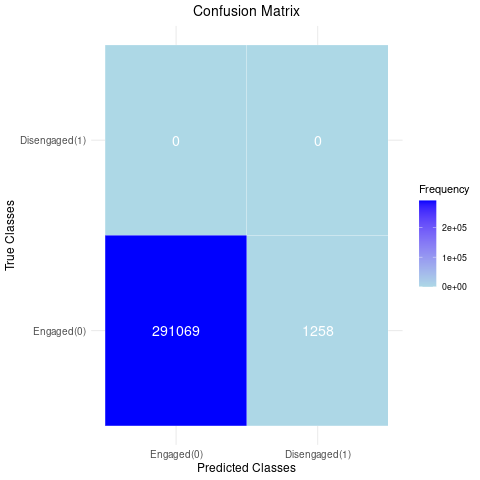

In [13]:
%%R
# Load required libraries
library(ggplot2)
library(caret)

# Map the values to labels (1 -> "Disengaged", 0 -> "Engaged")
predicted_classes_labeled <- factor(predicted_classes, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))
actual_classes_labeled <- factor(test_data$BinaryDisengagementExpanded, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))

# Generate the confusion matrix
cm <- confusionMatrix(predicted_classes_labeled, actual_classes_labeled)
cm_table <- as.data.frame(cm$table)

# Rename columns for better understanding
colnames(cm_table) <- c("Actual", "Predicted", "Frequency")

# Create the colored confusion matrix plot
ggplot(cm_table, aes(x = Predicted, y = Actual, fill = Frequency)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightblue", high = "blue", name = "Frequency") +
  geom_text(aes(label = Frequency), color = "white", size = 5) +
  labs(title = "Confusion Matrix", x = "Predicted Classes", y = "True Classes") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 14),
        axis.title = element_text(size = 12),
        axis.text = element_text(size = 10))

In [14]:
%%R
table(train_data$BinaryDisengagementExpanded)
table(test_data$BinaryDisengagementExpanded)


     0      1 
291069   1258 


In [15]:
%%R
library(caret)

# Convert the response variable to a factor
train_data$BinaryDisengagementExpanded <- as.factor(train_data$BinaryDisengagementExpanded)

# Downsample the majority class (0s) to match the minority class (1s)
set.seed(42)
train_data_balanced <- downSample(
  x = train_data[, c("speedMps", "throttlePercentage", "brakePercentage", "steeringPercentage", "LatLonTotalStdDev")], 
  y = train_data$BinaryDisengagementExpanded
)

# Check new distribution
table(train_data_balanced$Class)  # Should be balanced now


    0     1 
20172 20172 


In [16]:
%%R
# Rename 'Class' back to 'BinaryDisengagementExpanded'
train_data_balanced$BinaryDisengagementExpanded <- train_data_balanced$Class
train_data_balanced$Class <- NULL  # Optionally remove the 'Class' column

# Now you can train your model
model <- glm(
  BinaryDisengagementExpanded ~ speedMps + throttlePercentage + 
    brakePercentage + steeringPercentage + LatLonTotalStdDev,
  data = train_data_balanced,
  family = binomial
)

summary(model)


Call:
glm(formula = BinaryDisengagementExpanded ~ speedMps + throttlePercentage + 
    brakePercentage + steeringPercentage + LatLonTotalStdDev, 
    family = binomial, data = train_data_balanced)

Deviance Residuals: 
   Min      1Q  Median      3Q     Max  
-3.766  -1.065  -0.293   1.206   1.494  

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         0.1293641  0.0367341   3.522 0.000429 ***
speedMps           -0.0305943  0.0018792 -16.280  < 2e-16 ***
throttlePercentage  0.0092012  0.0006508  14.139  < 2e-16 ***
brakePercentage     0.0365759  0.0009137  40.031  < 2e-16 ***
steeringPercentage -0.0148201  0.0014086 -10.521  < 2e-16 ***
LatLonTotalStdDev   0.0400539  0.0053183   7.531 5.02e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 55929  on 40343  degrees of freedom
Residual deviance: 52715  on 40338  degrees of freedom
AIC: 52727

N

In [17]:
%%R
# Predict on the test set using the trained model
predictions <- predict(model, test_data, type = "response")

# Convert probabilities to binary classes (0 or 1)
predicted_classes <- ifelse(predictions > 0.5, 1, 0)

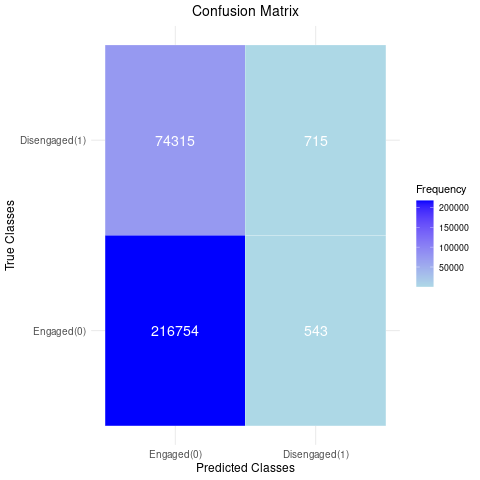

In [18]:
%%R
# Load required libraries
library(ggplot2)
library(caret)

# Convert actual and predicted values into factors for labeling
predicted_classes_labeled <- factor(predicted_classes, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))
actual_classes_labeled <- factor(test_data$BinaryDisengagementExpanded, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))

# Generate the confusion matrix
cm <- confusionMatrix(predicted_classes_labeled, actual_classes_labeled)
cm_table <- as.data.frame(cm$table)  # Convert to dataframe for visualization

# Rename columns for clarity
colnames(cm_table) <- c("Actual", "Predicted", "Frequency")

# Create the colored confusion matrix plot
ggplot(cm_table, aes(x = Predicted, y = Actual, fill = Frequency)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightblue", high = "blue", name = "Frequency") +
  geom_text(aes(label = Frequency), color = "white", size = 5) +
  labs(title = "Confusion Matrix", x = "Predicted Classes", y = "True Classes") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10)
  )

In [19]:
%%R
# Manually calculating the confusion matrix values
TP <- 715  # True Positives
FP <- 543     # False Positives
FN <- 74315  # False Negatives
TN <- 216754    # True Negatives

# Calculate Metrics
accuracy <- (TP + TN) / (TP + TN + FP + FN)  # Overall correctness
precision <- TP / (TP + FP)                  # Precision (Positive Predictive Value)
recall <- TP / (TP + FN)                     # Recall (Sensitivity)
f1_score <- 2 * ((precision * recall) / (precision + recall))  # F1-score

# Print Metrics
cat("Accuracy:", round(accuracy, 4), "\n")  
cat("Precision:", round(precision, 4), "\n")  
cat("Recall:", round(recall, 4), "\n")  
cat("F1-score:", round(f1_score, 4), "\n")  

Accuracy: 0.7439 
Precision: 0.5684 
Recall: 0.0095 
F1-score: 0.0187 


In [20]:
%%R
# Filter actual disengagement locations (Ground Truth)
actual_disengaged <- test_data[test_data$BinaryDisengagementExpanded == 1, ]

# Extract actual disengagement coordinates
actual_latitudes <- actual_disengaged$latitude
actual_longitudes <- actual_disengaged$longitude

# Filter test data where the model predicted Disengagement (1)
predicted_disengaged <- test_data[predicted_classes == 1, ]

# Extract predicted disengagement coordinates
predicted_latitudes <- predicted_disengaged$latitude
predicted_longitudes <- predicted_disengaged$longitude

# Ensure both actual and predicted lists have the same length
min_length <- min(length(actual_latitudes), length(predicted_latitudes))
actual_latitudes <- actual_latitudes[1:min_length]
actual_longitudes <- actual_longitudes[1:min_length]
predicted_latitudes <- predicted_latitudes[1:min_length]
predicted_longitudes <- predicted_longitudes[1:min_length]

# Create a data frame with actual and predicted disengagement locations
disengagement_comparison <- data.frame(
    actual_latitude = actual_latitudes,
    actual_longitude = actual_longitudes,
    predicted_latitude = predicted_latitudes,
    predicted_longitude = predicted_longitudes
)

# Display first few rows to verify
head(disengagement_comparison)

  actual_latitude actual_longitude predicted_latitude predicted_longitude
1        39.36517        -82.10235           39.36469           -82.10308
2        39.36517        -82.10235           39.36469           -82.10308
3        39.36517        -82.10235           39.36469           -82.10308
4        39.36517        -82.10235           39.36469           -82.10308
5        39.36517        -82.10235           39.36469           -82.10308
6        39.36517        -82.10235           39.36469           -82.10308


In [21]:
%%R
head(disengagement_comparison)
dim(disengagement_comparison)

[1] 1258    4


In [22]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd

# Activate the conversion between R and pandas
pandas2ri.activate()

# Convert R dataframe to Pandas dataframe
disengagement_comparison_py = ro.conversion.rpy2py(ro.r('disengagement_comparison'))

# Verify if it's a Pandas DataFrame now
print(type(disengagement_comparison_py))  # Should output <class 'pandas.core.frame.DataFrame'>
print(disengagement_comparison_py.shape)  # Check shape
print(disengagement_comparison_py.head()) # Check first few rows

<class 'pandas.core.frame.DataFrame'>
(1258, 4)
   actual_latitude  actual_longitude  predicted_latitude  predicted_longitude
1        39.365174        -82.102347           39.364691            -82.10308
2        39.365174        -82.102347           39.364691            -82.10308
3        39.365174        -82.102347           39.364691            -82.10308
4        39.365174        -82.102347           39.364691            -82.10308
5        39.365174        -82.102347           39.364691            -82.10308


(1258, 4)


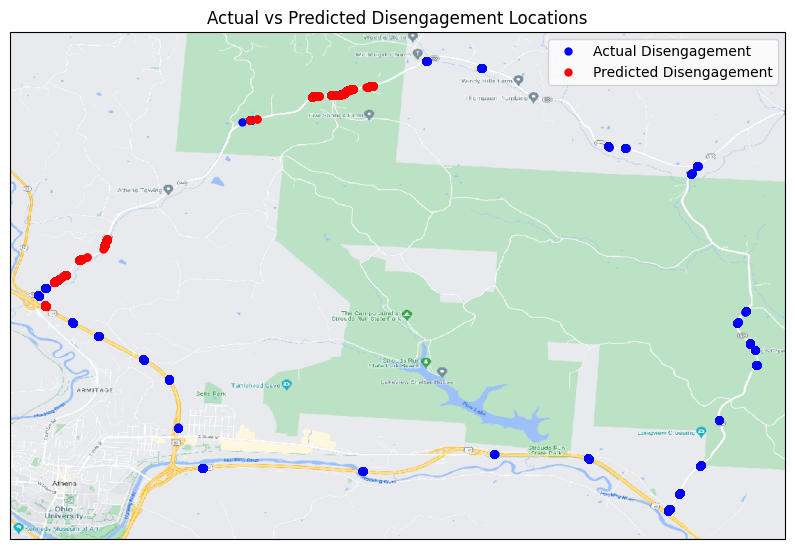

In [23]:
import cartopy.crs as ccrs
from cartopy.io.img_tiles import GoogleTiles
import matplotlib.pyplot as plt

# Define the dataframe for clarity
df = disengagement_comparison_py  

# Print shape for verification
print(df.shape)

# Define plot size
plt.figure(figsize=(10, 10))

# Get min and max latitude and longitude
minLat = df['actual_latitude'].min()
maxLat = df['actual_latitude'].max()
minLon = df['actual_longitude'].min()
maxLon = df['actual_longitude'].max()

# Define expansion coefficient to avoid edge cutoff
expansion_coeff = 0.005

# Load street map
street_map = GoogleTiles(style='street')

# Create plot with the street map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [minLon - expansion_coeff, maxLon + expansion_coeff, 
     minLat - expansion_coeff, maxLat + expansion_coeff],
    crs=ccrs.PlateCarree()
)

# Add map image
ax.add_image(street_map, 14)

# Extract actual and predicted disengagement locations
true_disengage_lat = df['actual_latitude']
true_disengage_lon = df['actual_longitude']

pred_disengage_lat = df['predicted_latitude']
pred_disengage_lon = df['predicted_longitude']

# Plot actual disengagement locations (Blue)
plt.plot(true_disengage_lon, true_disengage_lat,
         marker='o', ls='', color='blue', ms=5, label='Actual Disengagement', 
         transform=ccrs.PlateCarree())

# Plot predicted disengagement locations (Red)
plt.plot(pred_disengage_lon, pred_disengage_lat,
         marker='o', ls='', color='red', ms=5, label='Predicted Disengagement', 
         transform=ccrs.PlateCarree())

# Add title and legend
plt.title('Actual vs Predicted Disengagement Locations')
plt.legend()

# Show the plot
plt.show()